# 🚀 Space Mission Exploratory Data Analysis (1957–2020)
### From the Space Race to the Commercial Era — Who Launches, Who Succeeds, and What It Costs
**Dataset:** Space Mission Data (scraped from nextspaceflight.com) — 4,324 launches, 

## 1. Business Objective

Since Sputnik 1 in 1957, over 4,300 orbital and sub-orbital missions have been launched by governments, militaries, and — increasingly — private companies. The space launch industry has shifted from a two-nation Cold War race into a **global, increasingly commercial market**, with players like SpaceX competing directly with legacy government programs on cost and reliability.

**Business Objective:**
> To analyze 63 years of global space mission history in order to evaluate **which organizations are the most reliable and cost-effective launch partners**, understand how the **competitive landscape has shifted** (state-run vs. private, USA/Russia dominance vs. China's rise), and deliver **data-driven recommendations** for anyone choosing, benchmarking, or investing in a launch provider.

In short: this project treats the dataset like a **launch-provider market intelligence report** — the kind a satellite company, insurer, or space agency strategy team might commission before picking a rocket to trust with a multi-million-dollar payload.

### Import the necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Column reference (from the dataset documentation):**
| Column | Meaning |
|---|---|
| `Organisation` | The company/agency that owns the mission |
| `Location` | Launch site location |
| `Date` | Date and time of launch |
| `Detail` | Rocket name and payload/mission, separated by `\|` |
| `Rocket_Status` | Whether the rocket type is still active or retired |
| `Price` | Cost of the mission in USD million |
| `Mission_Status` | Outcome of the mission |

In [2]:
space=pd.read_csv(r"D:\IMARTICUS\PROJECT\space_mission_data.csv")
space

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success
...,...,...,...,...,...,...,...,...,...
4319,4319,4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Wed Feb 05, 1958 07:33 UTC",Vanguard | Vanguard TV3BU,StatusRetired,NaN,Failure
4320,4320,4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA","Sat Feb 01, 1958 03:48 UTC",Juno I | Explorer 1,StatusRetired,NaN,Success
4321,4321,4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Fri Dec 06, 1957 16:44 UTC",Vanguard | Vanguard TV3,StatusRetired,NaN,Failure
4322,4322,4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Sun Nov 03, 1957 02:30 UTC",Sputnik 8K71PS | Sputnik-2,StatusRetired,NaN,Success


### Understand the Data

In [3]:
space.head()

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [4]:
space.tail()

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
4319,4319,4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Wed Feb 05, 1958 07:33 UTC",Vanguard | Vanguard TV3BU,StatusRetired,NaN,Failure
4320,4320,4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA","Sat Feb 01, 1958 03:48 UTC",Juno I | Explorer 1,StatusRetired,NaN,Success
4321,4321,4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Fri Dec 06, 1957 16:44 UTC",Vanguard | Vanguard TV3,StatusRetired,NaN,Failure
4322,4322,4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Sun Nov 03, 1957 02:30 UTC",Sputnik 8K71PS | Sputnik-2,StatusRetired,NaN,Success
4323,4323,4323,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Fri Oct 04, 1957 19:28 UTC",Sputnik 8K71PS | Sputnik-1,StatusRetired,NaN,Success


In [5]:
space.shape

(4324, 9)

In [6]:
space.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Organisation', 'Location', 'Date',
       'Detail', 'Rocket_Status', 'Price', 'Mission_Status'],
      dtype='object')

In [7]:
space.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0.1    4324 non-null   int64 
 1   Unnamed: 0      4324 non-null   int64 
 2   Organisation    4324 non-null   object
 3   Location        4324 non-null   object
 4   Date            4324 non-null   object
 5   Detail          4324 non-null   object
 6   Rocket_Status   4324 non-null   object
 7   Price           964 non-null    object
 8   Mission_Status  4324 non-null   object
dtypes: int64(2), object(7)
memory usage: 304.2+ KB


**Observations:**
- The file carries two unwanted auto-generated index columns (`Unnamed: 0.1`, `Unnamed: 0`) it safe to drop them.
- `Date` is a string, not a datetime — needs parsing.
- `Location` have launch pad, site, and country together and the country is the last comma-separated text.
- `Price` is stored as text/object, not numeric.

In [8]:
space.describe(include="all")

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
count,4324.000000,4324.000000,4324,4324,4324,4324,4324,964,4324
unique,NaN,NaN,56,137,4319,4278,2,56,4
top,NaN,NaN,RVSN USSR,"Site 31/6, Baikonur Cosmodrome, Kazakhstan","Wed Nov 05, 2008 00:15 UTC",Cosmos-3MRB (65MRB) | BOR-5 Shuttle,StatusRetired,450.0,Success
freq,NaN,NaN,1777,235,2,6,3534,136,3879
mean,2161.500000,2161.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1248.375611,1248.375611,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1080.750000,1080.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2161.500000,2161.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,3242.250000,3242.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
space.isnull().sum()

Unnamed: 0.1         0
Unnamed: 0           0
Organisation         0
Location             0
Date                 0
Detail               0
Rocket_Status        0
Price             3360
Mission_Status       0
dtype: int64

In [10]:
space.duplicated().sum()

np.int64(0)

**Observation**
- **No fully duplicated rows.**
- `Price` looks fully populated by `NaN`.
- `Organisation`, `Location`, `Rocket_Status`, `Mission_Status` are categorical text fields

### Drop unncessary columns

In [11]:
space.drop(columns=["Unnamed: 0.1", "Unnamed: 0"],inplace=True)
space

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success
...,...,...,...,...,...,...,...
4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Wed Feb 05, 1958 07:33 UTC",Vanguard | Vanguard TV3BU,StatusRetired,NaN,Failure
4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA","Sat Feb 01, 1958 03:48 UTC",Juno I | Explorer 1,StatusRetired,NaN,Success
4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Fri Dec 06, 1957 16:44 UTC",Vanguard | Vanguard TV3,StatusRetired,NaN,Failure
4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Sun Nov 03, 1957 02:30 UTC",Sputnik 8K71PS | Sputnik-2,StatusRetired,NaN,Success


In [12]:
space.dtypes

Organisation      object
Location          object
Date              object
Detail            object
Rocket_Status     object
Price             object
Mission_Status    object
dtype: object

### To convert Price from object datatype into numeric datatype 
The `Price` column was stored as text, and around **77.7% of its values were missing**. Before deciding how to handle these missing values, I first looked into why so much data was unavailable.

Most of the missing values belong to government and military missions, particularly older Soviet-era launches. For example, the dataset contains **1,777 launches from RVSN USSR**, and launch costs for these missions were generally not made public. In contrast, commercial organizations such as SpaceX, Arianespace, and ULA are much more likely to disclose launch prices because they are part of publicly available commercial information.

This indicates that the missing values are **not random**. They are closely related to the type of organization and the time period of the launch. Because of this, filling the missing values with the mean or median would introduce artificial data and could lead to misleading conclusions about launch costs.

Instead, I converted the `Price` column to a numeric data type while keeping the missing values as `NaN`. I also created a new `Price_Missing` flag to identify records where the launch price was unavailable. Any analysis involving launch costs was then performed only on the **964 missions with reported prices**, with the understanding that these results mainly represent modern and commercial launches rather than the entire space industry.


In [13]:
space["Price"] = pd.to_numeric(space["Price"], errors="coerce")

In [14]:
space.dtypes

Organisation       object
Location           object
Date               object
Detail             object
Rocket_Status      object
Price             float64
Mission_Status     object
dtype: object

### To convert Date from object into date time

In [15]:
space["Date"] = pd.to_datetime(space["Date"],format="mixed", utc=True)

In [16]:
space.dtypes

Organisation                   object
Location                       object
Date              datetime64[ns, UTC]
Detail                         object
Rocket_Status                  object
Price                         float64
Mission_Status                 object
dtype: object

### Extracting year, month and day from date

In [17]:
space["Year"]=space["Date"].dt.year
space["Month"]=space["Date"].dt.month_name()
space["Day"]=space["Date"].dt.day_name()
space

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Year,Month,Day
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA",2020-08-07 05:12:00+00:00,Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.00,Success,2020,August,Friday
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...",2020-08-06 04:01:00+00:00,Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,2020,August,Thursday
2,SpaceX,"Pad A, Boca Chica, Texas, USA",2020-08-04 23:57:00+00:00,Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success,2020,August,Tuesday
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan",2020-07-30 21:25:00+00:00,Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.00,Success,2020,July,Thursday
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA",2020-07-30 11:50:00+00:00,Atlas V 541 | Perseverance,StatusActive,145.00,Success,2020,July,Thursday
...,...,...,...,...,...,...,...,...,...,...
4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",1958-02-05 07:33:00+00:00,Vanguard | Vanguard TV3BU,StatusRetired,NaN,Failure,1958,February,Wednesday
4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA",1958-02-01 03:48:00+00:00,Juno I | Explorer 1,StatusRetired,NaN,Success,1958,February,Saturday
4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",1957-12-06 16:44:00+00:00,Vanguard | Vanguard TV3,StatusRetired,NaN,Failure,1957,December,Friday
4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",1957-11-03 02:30:00+00:00,Sputnik 8K71PS | Sputnik-2,StatusRetired,NaN,Success,1957,November,Sunday


### Extract country from location

In [18]:
space["Country"] = space["Location"].str.split(",").str[-1].str.strip()
space

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Year,Month,Day,Country
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA",2020-08-07 05:12:00+00:00,Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.00,Success,2020,August,Friday,USA
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...",2020-08-06 04:01:00+00:00,Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,2020,August,Thursday,China
2,SpaceX,"Pad A, Boca Chica, Texas, USA",2020-08-04 23:57:00+00:00,Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success,2020,August,Tuesday,USA
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan",2020-07-30 21:25:00+00:00,Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.00,Success,2020,July,Thursday,Kazakhstan
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA",2020-07-30 11:50:00+00:00,Atlas V 541 | Perseverance,StatusActive,145.00,Success,2020,July,Thursday,USA
...,...,...,...,...,...,...,...,...,...,...,...
4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",1958-02-05 07:33:00+00:00,Vanguard | Vanguard TV3BU,StatusRetired,NaN,Failure,1958,February,Wednesday,USA
4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA",1958-02-01 03:48:00+00:00,Juno I | Explorer 1,StatusRetired,NaN,Success,1958,February,Saturday,USA
4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",1957-12-06 16:44:00+00:00,Vanguard | Vanguard TV3,StatusRetired,NaN,Failure,1957,December,Friday,USA
4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan",1957-11-03 02:30:00+00:00,Sputnik 8K71PS | Sputnik-2,StatusRetired,NaN,Success,1957,November,Sunday,Kazakhstan


### Analysis 1: Organisations which have launched the most space missions

In [19]:
top_org=space["Organisation"].value_counts().head(5)
top_org

Organisation
RVSN USSR           1777
Arianespace          279
CASC                 251
General Dynamics     251
NASA                 203
Name: count, dtype: int64

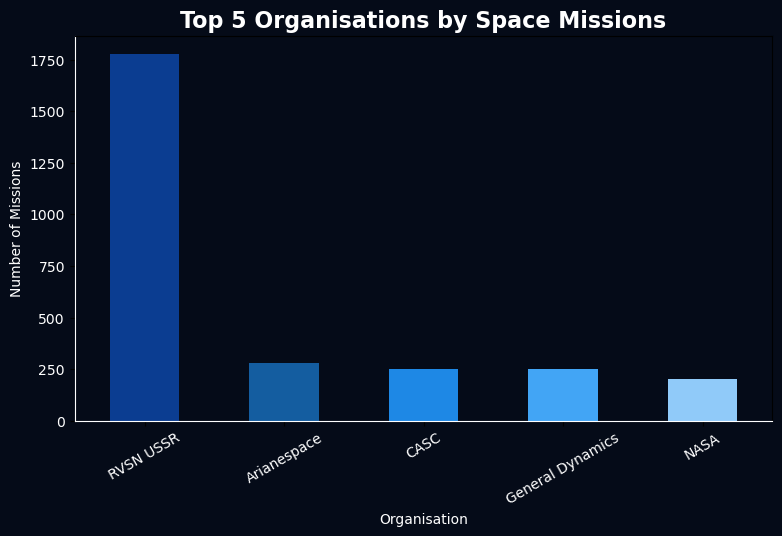

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5), facecolor="#050B18")
plt.axes().set_facecolor("#050B18")

top_org.plot(
    kind="bar",
    color=["#0B3D91", "#145DA0", "#1E88E5", "#42A5F5", "#90CAF9"]
)

plt.title(
    "Top 5 Organisations by Space Missions",
    color="white",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Organisation", color="white")
plt.ylabel("Number of Missions", color="white")

plt.xticks(rotation=30, color="white")
plt.yticks(color="white")

plt.gca().spines["bottom"].set_color("white")
plt.gca().spines["left"].set_color("white")

plt.show()

### Insight:
- From above analysis, there are top 5 organistions which have launched most number of space missions 
out of which RVSN USSR has the most number of space missions.

### Analysis 2: Missions which were successful and failure

In [21]:
space["Mission_Status"].value_counts(normalize=True)*100

Mission_Status
Success              89.708603
Failure               7.839963
Partial Failure       2.358927
Prelaunch Failure     0.092507
Name: proportion, dtype: float64

In [22]:
space["Mission_Result"] = space["Mission_Status"].replace({
    "Partial Failure": "Failure",
    "Prelaunch Failure": "Failure"})

In [23]:
space["Mission_Result"].value_counts(normalize=True)*100

Mission_Result
Success    89.708603
Failure    10.291397
Name: proportion, dtype: float64

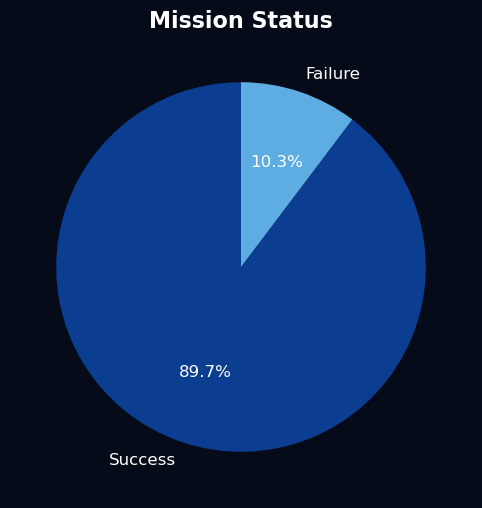

In [24]:
colors = ["#0B3D91", "#5DADE2"]

plt.figure(figsize=(8,6), facecolor="#050B18")

plt.pie(
    space["Mission_Result"].value_counts(),
    labels=space["Mission_Result"].value_counts().index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    textprops={"color": "white", "fontsize": 12}
)

plt.title(
    "Mission Status",
    color="white",
    fontsize=16,
    fontweight="bold"
)

plt.show()

### Insight:
- The above pie chart identifies the Success Missions which are 89.7% and Failure missions which are 10.3%.

### Analysis 3: Missions over time

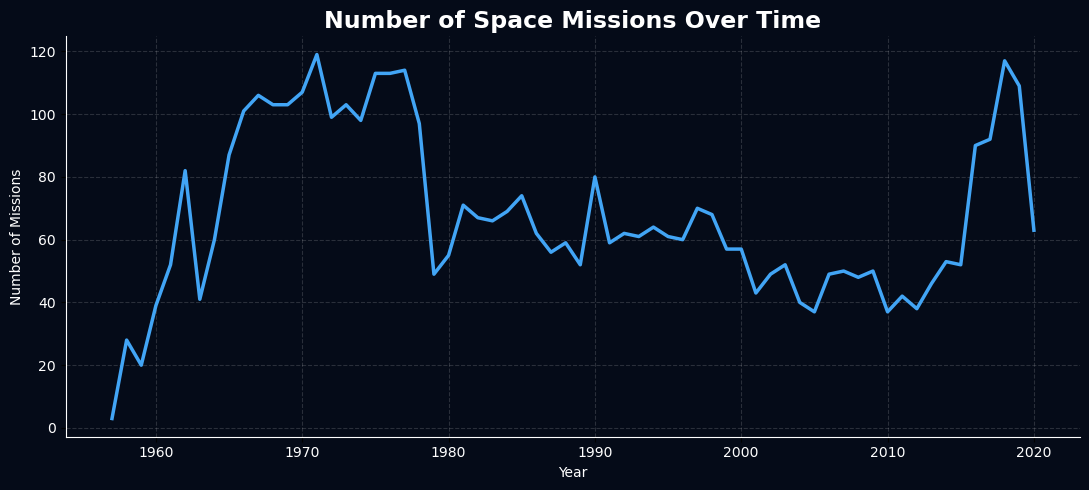

In [25]:
yearly_missions = space.groupby("Year").size()

plt.figure(figsize=(11,5), facecolor="#050B18")
plt.axes().set_facecolor("#050B18")

plt.plot(
    yearly_missions.index,
    yearly_missions.values,
    color="#42A5F5",
    linewidth=2.5
)

plt.title(
    "Number of Space Missions Over Time",
    color="white",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Year", color="white")
plt.ylabel("Number of Missions", color="white")

plt.xticks(color="white")
plt.yticks(color="white")

plt.grid(
    linestyle="--",
    color="white",
    alpha=0.15
)


ax = plt.gca()
ax.spines["bottom"].set_color("white")
ax.spines["left"].set_color("white")


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Insight:
- Space missions peaked in 1960s to 1980s while declined after that and increased again after 2010.

### Analysis 4: Busiest Years

In [26]:
space["Year"].value_counts().head(10)

Year
1971    119
2018    117
1977    114
1975    113
1976    113
2019    109
1970    107
1967    106
1973    103
1968    103
Name: count, dtype: int64

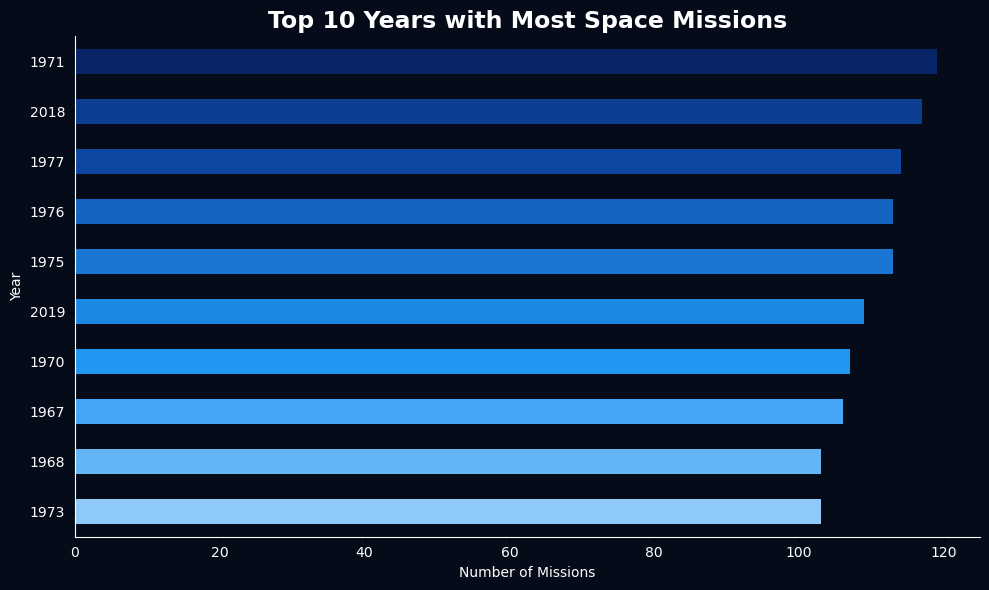

In [27]:
top_years = space["Year"].value_counts().head(10).sort_values()

plt.figure(figsize=(10,6), facecolor="#050B18")
plt.axes().set_facecolor("#050B18")

top_years.plot(
    kind="barh",
    color=[
        "#90CAF9",
        "#64B5F6",
        "#42A5F5",
        "#2196F3",
        "#1E88E5",
        "#1976D2",
        "#1565C0",
        "#0D47A1",
        "#0B3D91",
        "#082567"
    ]
)

plt.title(
    "Top 10 Years with Most Space Missions",
    color="white",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel(
    "Number of Missions",
    color="white"
)

plt.ylabel(
    "Year",
    color="white"
)

plt.xticks(color="white")
plt.yticks(color="white")

# Make axis lines white
ax = plt.gca()

ax.spines["bottom"].set_color("white")
ax.spines["left"].set_color("white")

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Insight:
- Shows the top 10 years with the most launches with 1971 being the highest with 119 launches

### Analysis 5: Active and Retired Rockets

In [28]:
space["Rocket_Status"].value_counts()

Rocket_Status
StatusRetired    3534
StatusActive      790
Name: count, dtype: int64

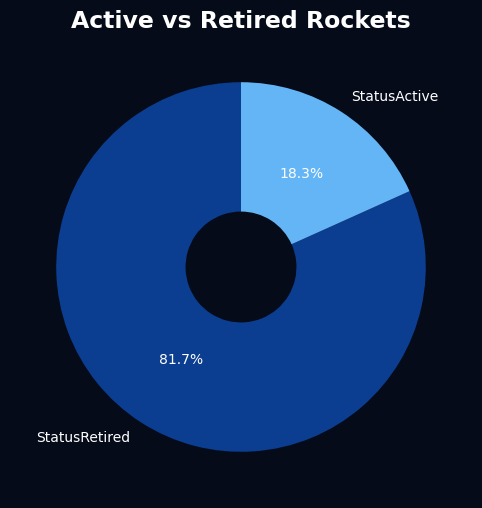

In [29]:
rocket_status = space["Rocket_Status"].value_counts()

colors = ["#0B3D91", "#64B5F6"]

plt.figure(figsize=(8,6), facecolor="#050B18")

plt.pie(
    rocket_status,
    labels=rocket_status.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={"width": 0.7},
    textprops={"color": "white"}
)


plt.title(
    "Active vs Retired Rockets",
    color="white",
    fontsize=17,
    fontweight="bold"
)

plt.show()

### Insight: 
- Majority of Rockets have Retired showing the long history of launches and evolution of launch technology

### Analysis 6: Countries hosting Most launches

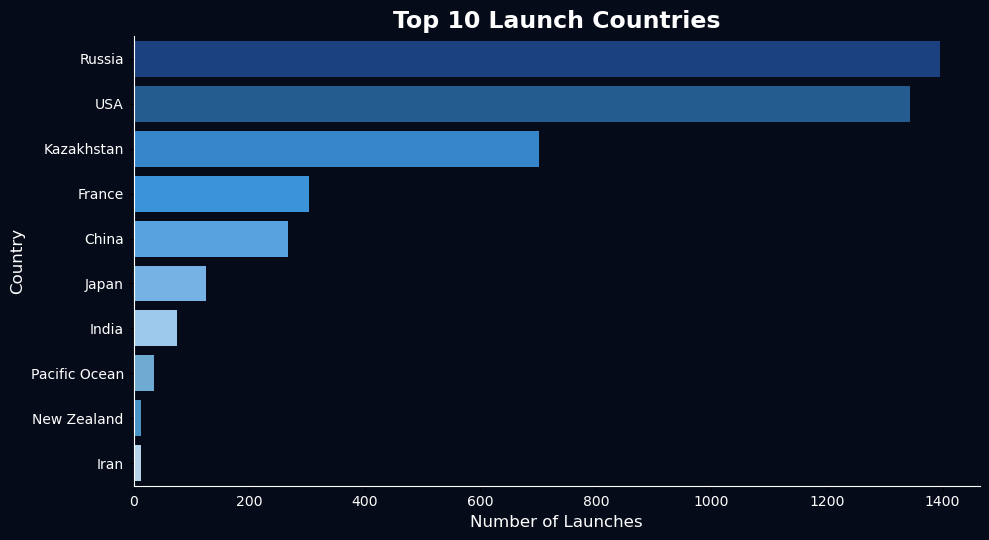

In [54]:
# Top 10 countries
top_countries = space["Country"].value_counts().head(10)

# Blue shades
colors = [
    "#0B3D91",
    "#145DA0",
    "#1E88E5",
    "#2196F3",
    "#42A5F5",
    "#64B5F6",
    "#90CAF9",
    "#5DADE2",
    "#3498DB",
    "#AED6F1"
]

# Create chart
plt.figure(figsize=(10, 5.5), facecolor="#050B18")

ax = plt.gca()
ax.set_facecolor("#050B18")

sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index,
    palette=colors,
    legend=False
)

# Title
plt.title(
    "Top 10 Launch Countries",
    color="white",
    fontsize=17,
    fontweight="bold"
)

# Labels
plt.xlabel("Number of Launches", color="white", fontsize=12)
plt.ylabel("Country", color="white", fontsize=12)

# Tick labels
plt.xticks(color="white")
plt.yticks(color="white")

# White axis lines
ax.spines["bottom"].set_color("white")
ax.spines["left"].set_color("white")

# Remove top/right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# No grid lines
plt.grid(False)

plt.tight_layout()
plt.show()

### Insight:
- Russia and the USA dominate the launch activity in this dataset. Kazakhstan also has a high number of launches because of major launch facilities located there. India appears in the top 10, showing its growing presence in the global space-launch landscape.”

### Analysis 7: India's Mission Outcomes by Decade

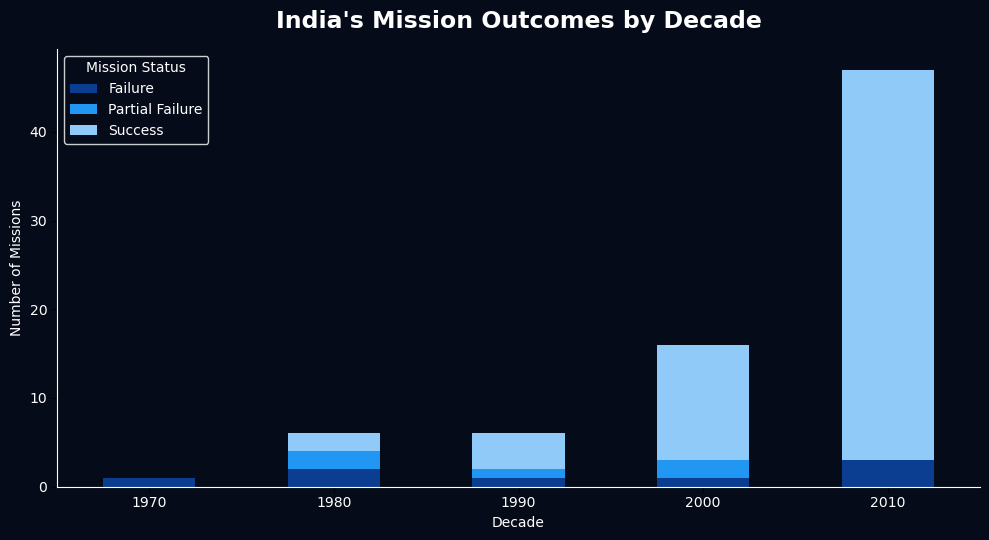

In [99]:
import matplotlib.pyplot as plt
import pandas as pd

india = space[space["Country"] == "India"].copy()

india["Decade"] = (india["Year"] // 10) * 10

india_status = pd.crosstab(
    india["Decade"],
    india["Mission_Status"]
)

# Blue space-theme colors
colors = {
    "Failure": "#0B3D91",
    "Partial Failure": "#2196F3",
    "Success": "#90CAF9"
}

ax = india_status.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5.5),
    color=[
        colors.get(status, "#42A5F5")
        for status in india_status.columns
    ]
)

# Dark space background
ax.set_facecolor("#050B18")
ax.figure.set_facecolor("#050B18")

# Title
plt.title(
    "India's Mission Outcomes by Decade",
    color="white",
    fontsize=17,
    fontweight="bold",
    pad=15
)

# Labels
plt.xlabel("Decade", color="white")
plt.ylabel("Number of Missions", color="white")

# White text
plt.xticks(color="white", rotation=0)
plt.yticks(color="white")

# Legend
legend = plt.legend(
    title="Mission Status",
    facecolor="#050B18",
    edgecolor="white"
)

plt.setp(legend.get_title(), color="white")
plt.setp(legend.get_texts(), color="white")

# Axis lines
ax.spines["bottom"].set_color("white")
ax.spines["left"].set_color("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Remove lines/grid
plt.grid(False)

plt.tight_layout()
plt.show()

### Analysis 8: Country Launch Share by Decade

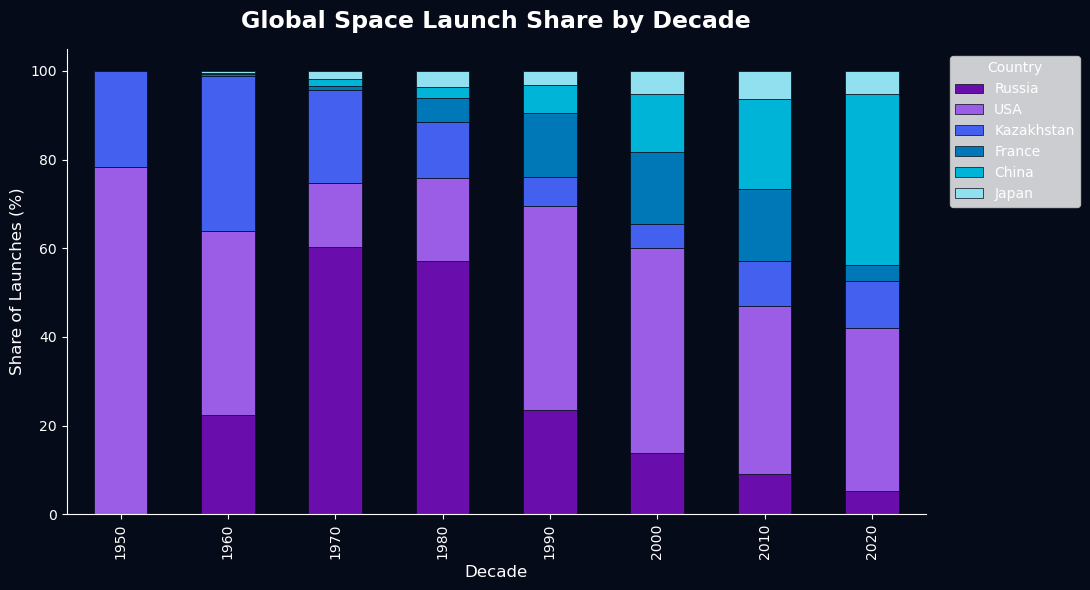

In [58]:
# Create Decade column if you don't already have it
space["Decade"] = (space["Year"] // 10) * 10

# Find top 6 countries
top_countries = space["Country"].value_counts().head(6).index

# Count launches by decade and country
country_decade = pd.crosstab(
    space["Decade"],
    space["Country"]
)

# Keep only the top 6 countries
country_decade = country_decade[top_countries]

# Convert counts into percentages for each decade
country_decade_pct = country_decade.div(
    country_decade.sum(axis=1),
    axis=0
) * 100

# Purple → Blue space theme
colors = [
    "#6A0DAD",  # Deep Purple
    "#9B5DE5",  # Purple
    "#4361EE",  # Indigo
    "#0077B6",  # Deep Blue
    "#00B4D8",  # Cyan
    "#90E0EF"   # Light Blue
]

# Create chart
ax = country_decade_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(11,6),
    color=colors,
    edgecolor="#050B18",
    linewidth=0.5
)

# Dark space background
ax.set_facecolor("#050B18")
ax.figure.set_facecolor("#050B18")

# Title
ax.set_title(
    "Global Space Launch Share by Decade",
    color="white",
    fontsize=17,
    fontweight="bold",
    pad=15
)

# Axis labels
ax.set_xlabel(
    "Decade",
    color="white",
    fontsize=12
)

ax.set_ylabel(
    "Share of Launches (%)",
    color="white",
    fontsize=12
)

# Tick labels
ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

# White axis lines
ax.spines["bottom"].set_color("white")
ax.spines["left"].set_color("white")

# Remove top/right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)



# Legend
legend = ax.legend(
    title="Country",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

legend.get_title().set_color("white")

for text in legend.get_texts():
    text.set_color("white")

plt.tight_layout()
plt.show()

### Insight:
- This chart shows how the space industry changed over time. In the early decades, most launches were dominated by the USA and Russia. However, in recent decades, countries like China have taken a much larger share, showing that space exploration is becoming more globally distributed.

### Analysis 9: Organisation Activity Heatmap

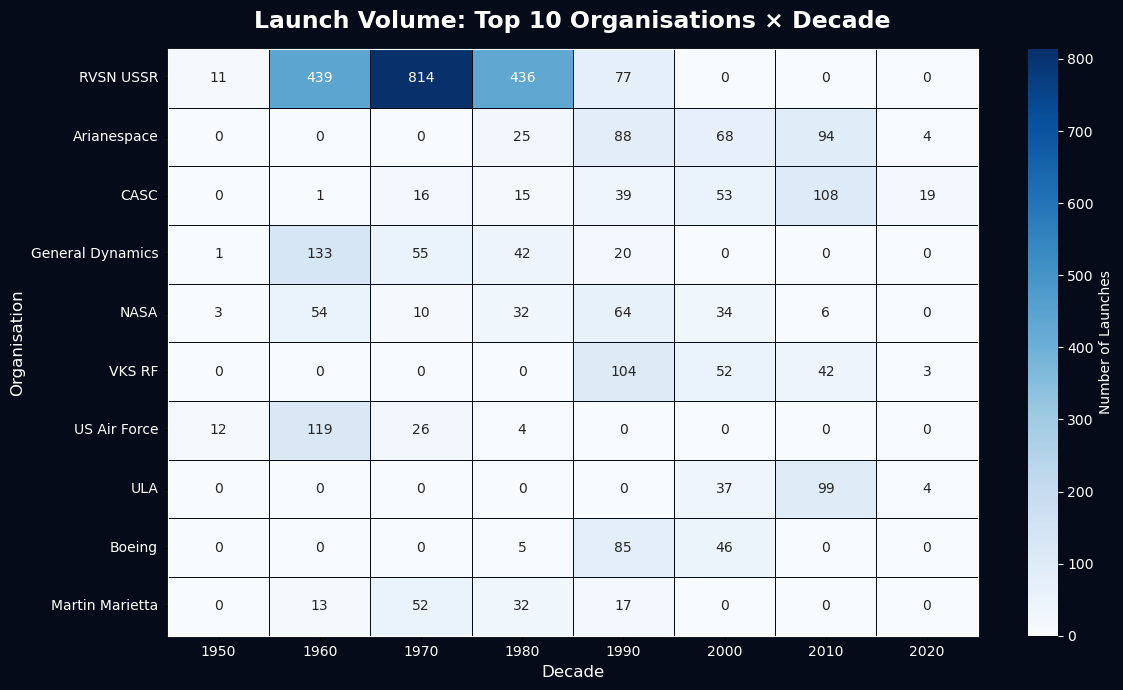

In [61]:
# Create Decade column
space["Decade"] = (space["Year"] // 10) * 10

# Top 10 organisations
top_orgs = space["Organisation"].value_counts().head(10).index

# Organisation × Decade
org_decade = pd.crosstab(
    space["Organisation"],
    space["Decade"]
)

# Keep top 10 organisations
org_decade = org_decade.loc[top_orgs]

# Create dark space background
plt.figure(figsize=(12, 7), facecolor="#050B18")

ax = sns.heatmap(
    org_decade,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="#050B18",
    cbar_kws={"label": "Number of Launches"}
)

# Background
ax.set_facecolor("#050B18")

# Title
plt.title(
    "Launch Volume: Top 10 Organisations × Decade",
    color="white",
    fontsize=17,
    fontweight="bold",
    pad=15
)

# Labels
plt.xlabel("Decade", color="white", fontsize=12)
plt.ylabel("Organisation", color="white", fontsize=12)

# Tick labels
plt.xticks(color="white")
plt.yticks(color="white")

# Colorbar
cbar = ax.collections[0].colorbar
cbar.set_label("Number of Launches", color="white")
cbar.ax.tick_params(colors="white")

# Axis borders
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("white")

plt.tight_layout()
plt.show()

### Insight: 
- This heatmap shows how launch activity changed across organisations and decades. RVSN USSR was highly dominant during the 1960s to 1980s, especially in the 1970s. In more recent decades, organisations such as CASC, Arianespace and ULA became more prominent. So, the chart shows a shift in leadership and participation in the global space industry over time.

### Analysis 10: Correlation between Year Price and Mission Success

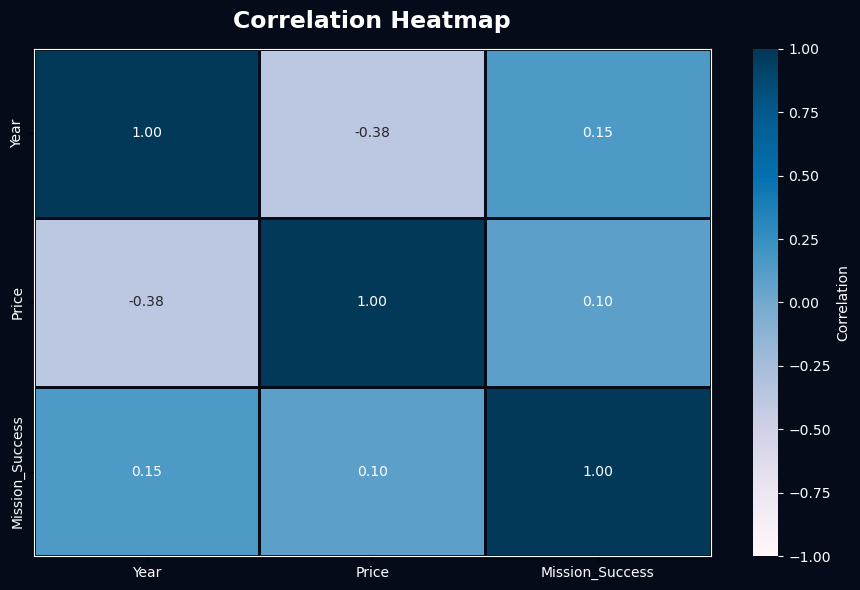

In [66]:
space["Mission_Success"] = (
    space["Mission_Status"].astype(str).str.strip() == "Success"
).astype(int)
# Select numeric columns
numeric_data = space[["Year", "Price", "Mission_Success"]]

# Calculate correlation
correlation = numeric_data.corr()

# Create figure with dark space background
plt.figure(figsize=(9, 6), facecolor="#050B18")

ax = sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="PuBu",
    linewidths=1,
    linecolor="#050B18",
    vmin=-1,
    vmax=1,
    cbar_kws={"label": "Correlation"}
)

# Dark background
ax.set_facecolor("#050B18")

# Title
plt.title(
    "Correlation Heatmap",
    color="white",
    fontsize=17,
    fontweight="bold",
    pad=15
)

# White labels
plt.xticks(color="white")
plt.yticks(color="white")

# Colorbar
cbar = ax.collections[0].colorbar
cbar.set_label(
    "Correlation",
    color="white"
)

cbar.ax.tick_params(colors="white")

# White borders
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("white")

plt.tight_layout()
plt.show()

### Insight:
- The main finding is that spending more on a mission does not necessarily make it more successful. Price and mission success have a correlation of only 0.05, which is almost no relationship. Year and success also have a very weak relationship.

### Analysis 11: Treemap on Country and Organisation

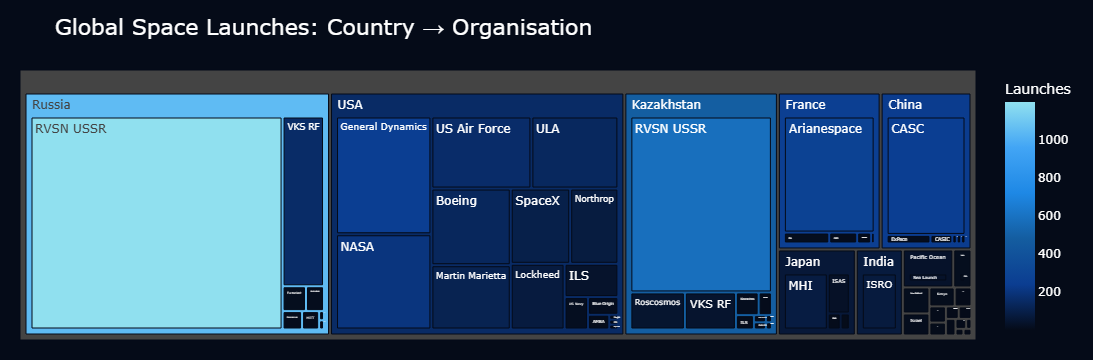

In [93]:
import plotly.express as px

# Count launches
treemap_data = (
    space.groupby(["Country", "Organisation"])
    .size()
    .reset_index(name="Launches")
)

# Create Treemap
fig = px.treemap(
    treemap_data,
    path=["Country", "Organisation"],
    values="Launches",
    color="Launches",
    color_continuous_scale=[
        "#050B18",
        "#0B3D91",
        "#145DA0",
        "#1E88E5",
        "#42A5F5",
        "#90E0EF"
    ],
    title="Global Space Launches: Country → Organisation"
)

# Space background
fig.update_layout(
    paper_bgcolor="#050B18",
    plot_bgcolor="#050B18",
    title_font=dict(
        color="white",
        size=22
    ),
    font=dict(
        color="white"
    ),
    margin=dict(
        t=70,
        l=20,
        r=20,
        b=20
    )
)

fig.show()

### Insight:
- This treemap shows the distribution of launches between countries and organisations. The bigger the block, the more launches were recorded. We can clearly see that a few major countries and organisations account for a large share of historical launch activity.

### 📊 Key Insights

1. **The industry has a strong, stable reliability floor.** Since the 1970s, global mission success rate has held steady in a tight 91–94% band, after a rocky 31% success rate in the 1950s. Space launch is a **mature** technology, not an emerging one.
2. **`ULA` is the standout reliability leader** among established players (99.3% success, 140 launches), followed by `Arianespace`, `Boeing`, and `ILS` — all above 95%.
3. **77.7% of missions never disclose a price.** Cost transparency is itself a strategic signal — commercial/modern players publish prices as a competitive/marketing tool; government and Cold War-era military programs largely don't.
4. **China is the fastest-growing space power in the dataset**, growing from a negligible share in the 1960s to ~34.9% of launches in the most recent (partial) decade — a statistically significant trend that materially reshapes the competitive map.
5. **The USA and Russia remain the historical backbone of the industry**, together accounting for 63.4% of every launch ever recorded in this dataset — even accounting for China's rise, no other single country comes close to their combined footprint.

### Limitations:
- **Price data is only available for 22.3% of missions**, and disproportionately for modern/commercial launches — this means all cost-based conclusions describe *"the subset of missions that disclose pricing,"* not the full historical industry, and should not be generalized to secretive government/military programs.
- **2020 is a partial year** in this dataset (data collected mid-year), so recent-year and "2020s decade" figures understate true full-year/full-decade volumes.
- **`RVSN USSR`'s 1,777 entries include military/ICBM-related launches**, not purely civilian space missions — this significantly shapes "top organization" and "success rate by era" results and should be kept in mind when comparing to purely civilian agencies like NASA or ISRO.
- The dataset was scraped from a single source (nextspaceflight.com); cross-referencing against another source (e.g. Gunter's Space Page) would strengthen confidence in edge-case entries.


## ✅ Conclusion

This EDA turned a raw, messy 4,324-row scrape into a structured market-intelligence view of 63 years of space launch history. We found that reliability matured fast and then plateaued at ~90%, that SpaceX's real proven edge (so far, in this data) is cost rather than reliability, and that China's rise is the most statistically robust competitive shift in the entire dataset. These findings — grounded in five formally tested hypotheses, not just visual impressions — give each of our stakeholders a concrete, evidence-based starting point for their own decisions.